# 02b · Where the rental properties are (Sprint 1 geo visualisation)

**Sprint 1 asks for** at least one way of showing the geolocation of the properties on a map and/or shapefile,
plus suitable attributes and external datasets. This notebook covers both:

1. **Attributes per snapshot**: which columns each data source gives us, and how complete they are.
2. **Point map**: every listing on the ABS SA2 **shapefile**, coloured by weekly rent.
3. **SA2 maps (shapefile)**: number of listings and median rent in each SA2 district.
4. **Change map**: SA2 median rent change between snapshots (appears once a second snapshot exists).
5. **Interactive map**: one circle per suburb (size = listings, colour = median rent), one layer per snapshot,
   plus a train-station layer.

**Built to take the 2026 data automatically.** The listings come from `scripts/listings.py`, which stacks every
snapshot whose file exists (today: Domain.com.au, Sept 2025; later: rent.com.au, Sept 2026) with the same columns.
Every map loops over the snapshots, so once the 2026 file is added, re-running this notebook draws the 2026 maps
and the change map with no code changes.

**Outputs** (in `plots/`): `map_listing_points.png`, `map_sa2_listing_count_<snapshot>.png`,
`map_sa2_listing_rent_<snapshot>.png`, `map_sa2_rent_change_<from>_to_<to>.png` and the interactive
`listings_map_suburbs.html`. The interactive map only holds suburb-level summaries, never individual listings,
because the repo is public and the Domain data can't be redistributed. SA2 maps of income, population, density
and projected growth are in `04_abs_sa2_crosswalk`.

**Data:** Domain.com.au listings, Sept 2025 (MAST30034 course dataset). ABS ASGS Edition 3 SA2 2021 boundaries
(`data/raw/external/SA2_2021_AUST_SHP_GDA2020.zip`). PTV GTFS timetable for train stations
(`data/raw/external/gtfs.zip`, optional).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "scripts"))   # shared project code

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm, TwoSlopeNorm
import folium
import branca.colormap as bcm

import config, style, geo
import listings as L
style.apply()

MELB = (144.55, 145.45, -38.15, -37.55)   # Greater Melbourne view: lon min, lon max, lat min, lat max

## 1. Listings and attributes per snapshot

In [2]:
df = L.build_listings(save=False)          # every snapshot we have, same columns
use = df[df["usable"]].copy()              # residential, plausible rent, valid coordinates
snapshots = sorted(df["snapshot"].unique())

df.groupby(["snapshot", "source"]).agg(
    listings=("listing_id", "size"),
    usable_for_maps=("usable", "sum"),
    suburbs=("suburb_key", "nunique"),
    median_weekly_rent=("weekly_rent", "median"),
)

,,listings,usable_for_maps,suburbs,median_weekly_rent
snapshot,source,,,,
2025-09,domain,12717,12291,654,560.0


**Which attributes each source provides** (% of listings with a value). The rent.com.au scraper collects the
same core columns as the Domain dataset (rent, bedrooms, bathrooms, car spaces, type, location, listing date, bond,
features, agency, photo count).

In [3]:
attrs = ["weekly_rent", "bond", "bedrooms", "bathrooms", "carspaces", "property_type", "lat", "lon",
         "date_listed", "days_listed", "agency", "features_text", "photo_count"]
coverage = df[attrs].notna().groupby(df["snapshot"]).mean().T.mul(100).round(0)
coverage.columns = [f"{c} (% filled)" for c in coverage.columns]
coverage

,2025-09 (% filled)
weekly_rent,98.0
bond,94.0
bedrooms,99.0
bathrooms,100.0
carspaces,86.0
property_type,100.0
lat,100.0
lon,100.0
date_listed,100.0
days_listed,100.0


## 2. Every listing on the SA2 shapefile

Each dot is one listing, coloured by weekly rent (colour capped at the 5th and 95th percentiles so a few very
expensive listings don't wash out the scale). The grey outlines are the ABS SA2 districts.

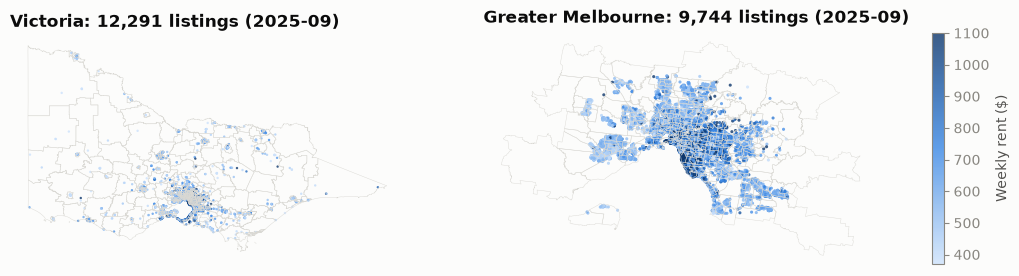

In [4]:
sa2 = geo.load_sa2_vic() if config.SA2_ZIP.exists() else None
if sa2 is None:
    print(f"SA2 shapefile not found at {config.SA2_ZIP}; maps are drawn without district outlines.")

vmin, vmax = use["weekly_rent"].quantile([0.05, 0.95])
fig, axes = plt.subplots(len(snapshots), 2, figsize=(14, 6 * len(snapshots)), squeeze=False)
for row, snap in enumerate(snapshots):
    g = use[use["snapshot"] == snap]
    for ax, box, title in [(axes[row, 0], None, "Victoria"), (axes[row, 1], MELB, "Greater Melbourne")]:
        pts = g if box is None else g[g["lon"].between(box[0], box[1]) & g["lat"].between(box[2], box[3])]
        if sa2 is not None:
            base = sa2 if box is None else sa2.cx[box[0]:box[1], box[2]:box[3]]
            base.boundary.plot(ax=ax, color="#d9d8d3", linewidth=0.3)
        sc = ax.scatter(pts["lon"], pts["lat"], c=pts["weekly_rent"], cmap=style.SEQ, vmin=vmin, vmax=vmax,
                        s=3 if box is None else 5, alpha=0.8, linewidths=0)
        ax.set_title(f"{title}: {len(pts):,} listings ({snap})")
        ax.set_aspect("equal")
        ax.set_axis_off()
fig.colorbar(sc, ax=axes, shrink=0.5, label="Weekly rent ($)")
fig.savefig(config.PLOTS / "map_listing_points.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. SA2 districts: how many listings, and median rent

Listings are placed in SA2 districts with a point-in-polygon join on their coordinates. The count map uses a
log scale because a few inner-city SA2s have hundreds of listings. The rent map only shows SA2s with at least
5 listings (grey = fewer), so one unusual listing can't set a district's colour.

Listings inside an SA2: 100.0%


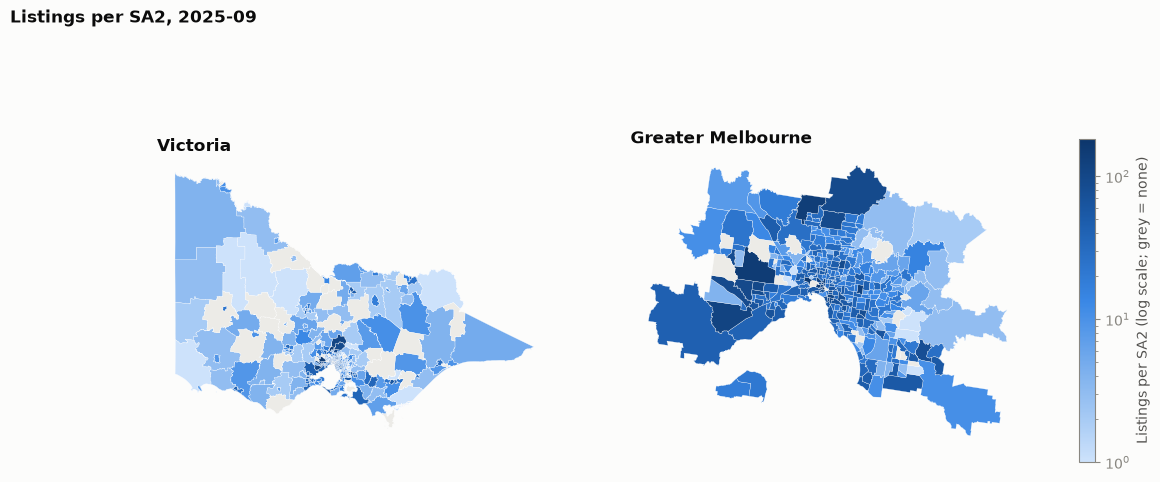

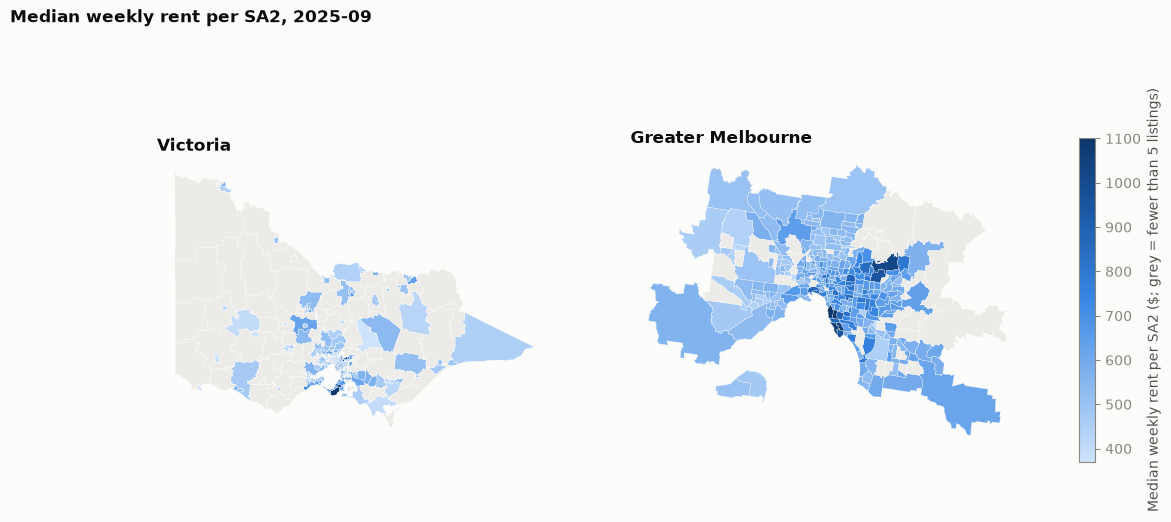

In [5]:
if sa2 is not None:
    use = geo.attach_sa2(use, sa2)
    per_sa2 = (use.groupby(["snapshot", "SA2_CODE21"])["weekly_rent"]
                  .agg(listings="size", median_rent="median").reset_index())
    print(f"Listings inside an SA2: {use['SA2_CODE21'].notna().mean():.1%}")

    panels = [("listings", LogNorm(1, per_sa2["listings"].max()), "Listings per SA2", "log scale; grey = none",
               "map_sa2_listing_count"),
              ("median_rent", plt.Normalize(vmin, vmax), "Median weekly rent per SA2",
               "$; grey = fewer than 5 listings", "map_sa2_listing_rent")]
    for snap in snapshots:
        m = sa2.merge(per_sa2[per_sa2["snapshot"] == snap], on="SA2_CODE21", how="left")
        m.loc[m["listings"] < 5, "median_rent"] = np.nan
        for column, norm, title, note, filename in panels:
            fig, axes = plt.subplots(1, 2, figsize=(14, 6))
            for ax, box, view in [(axes[0], None, "Victoria"), (axes[1], MELB, "Greater Melbourne")]:
                part = m if box is None else m.cx[box[0]:box[1], box[2]:box[3]]
                part.plot(column=column, cmap=style.SEQ, norm=norm, ax=ax, edgecolor="white", linewidth=0.2,
                          missing_kwds={"color": "#ecebe7"})
                ax.set_title(view)
                ax.set_axis_off()
            fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=style.SEQ), ax=axes, shrink=0.7,
                         label=f"{title} ({note})")
            fig.suptitle(f"{title}, {snap}", x=0.02, ha="left", fontweight="bold")
            fig.savefig(config.PLOTS / f"{filename}_{snap}.png", dpi=150, bbox_inches="tight")
            plt.show()

## 4. Change between snapshots (drawn automatically once there are two)

Percentage change in each SA2's median weekly rent from the first to the latest snapshot, for SA2s with at least
5 listings in both. Red = rent went up, blue = went down, grey = about the same. The two snapshots come from
different websites, so part of any change can be a website difference, not a market change.

In [6]:
if sa2 is not None and len(snapshots) >= 2:
    first, last = snapshots[0], snapshots[-1]
    wide = per_sa2[per_sa2["listings"] >= 5].pivot(index="SA2_CODE21", columns="snapshot", values="median_rent")
    change = (wide[last] / wide[first] - 1).mul(100).rename("change_pct").dropna()
    m = sa2.merge(change, left_on="SA2_CODE21", right_index=True, how="left")
    lim = max(5, change.abs().quantile(0.95))
    diverging = LinearSegmentedColormap.from_list("blue_grey_red", ["#2a78d6", "#f0efec", "#e34948"])
    norm = TwoSlopeNorm(0, -lim, lim)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, box, view in [(axes[0], None, "Victoria"), (axes[1], MELB, "Greater Melbourne")]:
        part = m if box is None else m.cx[box[0]:box[1], box[2]:box[3]]
        part.plot(column="change_pct", cmap=diverging, norm=norm, ax=ax, edgecolor="white", linewidth=0.2,
                  missing_kwds={"color": "#ecebe7"})
        ax.set_title(view)
        ax.set_axis_off()
    fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=diverging), ax=axes, shrink=0.7,
                 label="Change in SA2 median rent (%); grey = too few listings")
    fig.suptitle(f"Median rent change per SA2, {first} to {last}", x=0.02, ha="left", fontweight="bold")
    fig.savefig(config.PLOTS / f"map_sa2_rent_change_{first}_to_{last}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"{len(change)} SA2s in both snapshots; median change {change.median():+.1f}%")
else:
    print(f"Only one snapshot loaded ({snapshots[0]}). This map appears once the 2026 rent.com.au data is added.")

Only one snapshot loaded (2025-09). This map appears once the 2026 rent.com.au data is added.


## 5. Interactive map (suburb level)

One circle per suburb and snapshot: size shows the number of listings, colour the median weekly rent. Use the
layer box (top right) to switch snapshots and to show train stations. Only suburb-level summaries are put on this
map (no individual listings), so it can be shared. Saved to `plots/listings_map_suburbs.html`.

In [7]:
suburbs = (use.groupby(["snapshot", "suburb_key"])
              .agg(suburb=("suburb", "first"), postcode=("postcode", "first"), listings=("listing_id", "size"),
                   median_rent=("weekly_rent", "median"), lat=("lat", "median"), lon=("lon", "median"))
              .reset_index())
colours = bcm.LinearColormap(["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"], vmin=vmin, vmax=vmax,
                             caption="Suburb median weekly rent ($)")

m = folium.Map(location=[-37.81, 144.96], zoom_start=9, tiles="OpenStreetMap")
for snap in snapshots:
    layer = folium.FeatureGroup(name=f"Suburbs, {snap}", show=snap == snapshots[-1])
    for r in suburbs[suburbs["snapshot"] == snap].itertuples():
        folium.CircleMarker(
            location=[r.lat, r.lon], radius=3 + np.sqrt(r.listings) / 1.5,
            color="white", weight=1, fill=True, fill_color=colours(min(max(r.median_rent, vmin), vmax)),
            fill_opacity=0.85,
            tooltip=f"{r.suburb.title()} {r.postcode} ({snap})<br>Median rent: ${r.median_rent:,.0f}/wk"
                    f"<br>Listings: {r.listings}",
        ).add_to(layer)
    layer.add_to(m)

if config.GTFS_ZIP.exists():
    stations = folium.FeatureGroup(name="Train stations", show=False)
    for s in geo.train_stations().itertuples():
        folium.CircleMarker([s.lat, s.lon], radius=2, color="#52514e", fill=True, weight=0,
                            fill_opacity=0.9, tooltip=f"{s.name} station").add_to(stations)
    stations.add_to(m)

colours.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)
m.save(config.PLOTS / "listings_map_suburbs.html")
print(f"Saved plots/listings_map_suburbs.html ({len(suburbs):,} suburb circles)")
m

Saved plots/listings_map_suburbs.html (644 suburb circles)


## Summary

* The listings cover the whole state, heavily concentrated in Greater Melbourne and the regional cities
  (Geelong, Ballarat, Bendigo).
* Rents are highest in the inner and bayside south-east SA2s and fall with distance from the CBD; regional
  districts are the cheapest. Sprint 3 turns this into measured driving distances (`05b_accessibility_features`).
* The SA2 shapefile join is also the link to SA2 population and income data (Sprint 2, `04_abs_sa2_crosswalk`).
* When the 2026 rent.com.au data is added, re-run this notebook: every map gains a 2026 version and section 4
  shows the change.